# 02 — Modelagem com Redes Neurais (MLP PyTorch)

**Objetivo:** Construir, treinar e avaliar um MLP com PyTorch comparando-o contra baselines lineares e baseados em árvores no dataset Telco-Customer-Churn.

| Item | Detalhe |
|------|---------|
| Modelos | Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, **MLP** |
| Métricas | Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC |
| Rastreamento | MLflow (SQLite backend) |
| Análise de custo | FP (campanha desnecessária) vs. FN (churn não detectado) |

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import hashlib
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import mlflow
import mlflow.pytorch
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
)

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
print(f'MLflow   : {mlflow.__version__}')

PyTorch  : 2.12.0+cpu
CUDA     : False
MLflow   : 3.13.0


In [2]:
# ── Constantes de caminho e MLflow ────────────────────────────────────────────
DATA_PATH           = os.path.join('..', 'dataset', 'Dataset Telco-Customer-Churn.csv')
MLFLOW_DB_PATH      = os.path.abspath(os.path.join('..', 'mlflow.db'))
MLFLOW_TRACKING_URI = f'sqlite:///{MLFLOW_DB_PATH}'
EXPERIMENT_NAME     = 'Telco-Churn-MLP-Comparison'
ARTIFACT_ROOT       = os.path.abspath(os.path.join('..', 'mlruns', 'artifacts', 'mlp_experiment'))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {DEVICE}')
print(f'MLflow   : {MLFLOW_TRACKING_URI}')

Device   : cpu
MLflow   : sqlite:///c:\Users\Hugo\OneDrive\Documentos\Projeto Pós\ml-project\mlflow.db


## 2. Modelo de Custo de Negócio

| Métrica | Fórmula | Significado |
|---------|---------|-------------|
| **COST_FN** | ARPU × 12 | Receita perdida por cada churner não detectado |
| **COST_FP** | ARPU × 0.30 | Custo da campanha de retenção para não-churner |
| **Savings** | TP × ARPU × 12 × 0.40 | Receita salva (40% dos churners detectados retidos) |

In [3]:
# ── Modelo de custo derivado do dataset ───────────────────────────────────────
_df_cost = pd.read_csv(DATA_PATH)
_df_cost['TotalCharges'] = pd.to_numeric(_df_cost['TotalCharges'], errors='coerce')

ARPU             = round(float(_df_cost['MonthlyCharges'].median()), 2)
MONTHS_RETAINED  = 12
RETENTION_RATE   = 0.40
CAMPAIGN_COST    = round(ARPU * 0.30, 2)
COST_FN          = round(ARPU * MONTHS_RETAINED, 2)
COST_FP          = CAMPAIGN_COST

print('Modelo de Custo:')
print(f'  ARPU (mediana)      : R$ {ARPU:.2f}/mês')
print(f'  COST_FN (FN)        : R$ {COST_FN:.2f}  — receita perdida por churn não detectado')
print(f'  COST_FP (FP)        : R$ {COST_FP:.2f}  — campanha de retenção desnecessária')
print(f'  Razão FN/FP         : {COST_FN/COST_FP:.1f}× — custo do falso negativo é muito maior')

Modelo de Custo:
  ARPU (mediana)      : R$ 70.35/mês
  COST_FN (FN)        : R$ 844.20  — receita perdida por churn não detectado
  COST_FP (FP)        : R$ 21.10  — campanha de retenção desnecessária
  Razão FN/FP         : 40.0× — custo do falso negativo é muito maior


## 3. Dados

In [4]:
# ── Carrega e limpa o dataset ─────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

# TotalCharges contém espaços em clientes com tenure=0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Codifica target como binário (1 = Churn)
df_model = df.drop(columns=['customerID']).copy()
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

y   = df_model['Churn']
X_raw = df_model.drop(columns=['Churn'])
X   = pd.get_dummies(X_raw, drop_first=True)

print(f'Amostras  : {len(df):,}')
print(f'Features  : {X.shape[1]}')
print(f'Churn rate: {y.mean()*100:.2f}%  (desbalanceado)')
print(f'\nFeatures ({X.shape[1]}): {list(X.columns)}')

Amostras  : 7,043
Features  : 30
Churn rate: 26.54%  (desbalanceado)

Features (30): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [5]:
# ── Divisão treino / teste ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Escalamento para LR e MLP
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f'Treino : {len(X_train):,} amostras | Churn = {y_train.mean()*100:.2f}%')
print(f'Teste  : {len(X_test):,}  amostras | Churn = {y_test.mean()*100:.2f}%')
print(f'pos_weight (para BCEWithLogitsLoss): {(y_train==0).sum()/(y_train==1).sum():.2f}')

Treino : 5,634 amostras | Churn = 26.54%
Teste  : 1,409  amostras | Churn = 26.54%
pos_weight (para BCEWithLogitsLoss): 2.77


## 4. MLflow

In [6]:
# ── Configuração MLflow + versionamento do dataset ────────────────────────────
with open(os.path.abspath(DATA_PATH), 'rb') as _f:
    DATASET_HASH = hashlib.md5(_f.read()).hexdigest()
DATASET_VERSION = DATASET_HASH[:8]

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
exp = mlflow.set_experiment(EXPERIMENT_NAME)

BASE_TAGS = {
    'project'         : 'telco-churn',
    'dataset_version' : DATASET_VERSION,
    'notebook'        : '02_MLP_Modeling',
    'split'           : 'stratified_80_20',
}

print(f'Experimento : {EXPERIMENT_NAME}')
print(f'Dataset hash: {DATASET_VERSION}')
print(f'Tracking URI: {MLFLOW_TRACKING_URI}')

Experimento : Telco-Churn-MLP-Comparison
Dataset hash: 0f9de68e
Tracking URI: sqlite:///c:\Users\Hugo\OneDrive\Documentos\Projeto Pós\ml-project\mlflow.db


## 5. Funções Auxiliares

In [7]:
def compute_metrics(y_true, y_pred, y_prob):
    """Retorna dicionário com 6 métricas de avaliação."""
    return {
        'accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc'  : round(roc_auc_score(y_true, y_prob), 4),
        'pr_auc'   : round(average_precision_score(y_true, y_prob), 4),
    }


def compute_business_metrics(y_true, y_pred):
    """Retorna métricas financeiras com base no modelo de custo."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost_fn_total = fn * COST_FN
    cost_fp_total = fp * COST_FP
    savings       = tp * ARPU * MONTHS_RETAINED * RETENTION_RATE
    net_value     = savings - cost_fp_total
    return {
        'biz_tp'        : int(tp),  'biz_fp': int(fp),
        'biz_tn'        : int(tn),  'biz_fn': int(fn),
        'biz_cost_fn'   : round(cost_fn_total, 2),
        'biz_cost_fp'   : round(cost_fp_total, 2),
        'biz_savings'   : round(savings, 2),
        'biz_net_value' : round(net_value, 2),
    }


def find_best_threshold(y_true, y_prob, n_steps=81):
    """Varre thresholds e retorna aquele que maximiza o valor líquido."""
    best_thr, best_val = 0.5, float('-inf')
    for thr in np.linspace(0.1, 0.9, n_steps):
        preds = (y_prob >= thr).astype(int)
        net   = compute_business_metrics(y_true, preds)['biz_net_value']
        if net > best_val:
            best_val = net
            best_thr = float(thr)
    return round(best_thr, 2), round(best_val, 2)


def save_cm_figure(y_true, y_pred, name, artifact_dir):
    os.makedirs(artifact_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    path = os.path.join(artifact_dir, 'confusion_matrix.png')
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    return path


print('Funções auxiliares definidas.')

Funções auxiliares definidas.


## 6. Baselines Scikit-Learn

Quatro modelos servem de linha de base para comparação com o MLP:

| Modelo | Tipo | Regularização |
|--------|------|---------------|
| Logistic Regression | Linear | L2 (C=1) |
| Decision Tree | Árvore | max_depth=5, class_weight=balanced |
| Random Forest | Ensemble bagging | 200 árvores, class_weight=balanced |
| Gradient Boosting | Ensemble boosting | 200 árvores, lr=0.05 |

In [8]:
def train_sklearn_baseline(name, model_obj, X_tr, y_tr, X_te, y_te, artifact_dir):
    """Treina, avalia e loga um modelo sklearn no MLflow."""
    model_obj.fit(X_tr, y_tr)
    y_pred = model_obj.predict(X_te)
    y_prob = model_obj.predict_proba(X_te)[:, 1]

    metrics  = compute_metrics(y_te, y_pred, y_prob)
    biz      = compute_business_metrics(y_te, y_pred)
    opt_thr, opt_net = find_best_threshold(y_te, y_prob)
    cm_path  = save_cm_figure(y_te, y_pred, name, artifact_dir)

    with mlflow.start_run(run_name=name):
        mlflow.set_tags({**BASE_TAGS, 'model_type': name})
        safe_params = {
            k: str(v) for k, v in model_obj.get_params().items()
            if not callable(v) and not isinstance(v, dict)
        }
        mlflow.log_params({'model': name, **safe_params})
        mlflow.log_metrics({**metrics, **biz,
                            'optimal_threshold': opt_thr,
                            'optimal_net_value': opt_net})
        mlflow.log_artifact(cm_path)
        mlflow.sklearn.log_model(model_obj, artifact_path='model')

    print(f'{name:<25} | AUC={metrics["roc_auc"]:.4f} | F1={metrics["f1"]:.4f} | '
          f'Recall={metrics["recall"]:.4f} | Net=R${opt_net:,.0f}')
    return metrics, biz, y_pred, y_prob, opt_thr, opt_net


print('Função train_sklearn_baseline definida.')

Função train_sklearn_baseline definida.


In [9]:
# ── Treina os 4 baselines ─────────────────────────────────────────────────────
all_results    = {}   # nome → métricas
all_probs_dict = {}   # nome → y_prob (para curvas ROC/PR)
all_preds_dict = {}   # nome → y_pred
biz_results    = {}   # nome → {net_values por threshold}

print('Treinando baselines...\n')

# 1. Logistic Regression (com StandardScaler embutido no Pipeline)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, C=1.0)),
])
m, b, p, prob, thr, net = train_sklearn_baseline(
    'LogisticRegression', lr_pipeline,
    X_train.values, y_train.values, X_test.values, y_test.values,
    os.path.join(ARTIFACT_ROOT, 'lr')
)
all_results['LogisticRegression'] = {**m, 'opt_net': net, 'opt_thr': thr}
all_probs_dict['LogisticRegression'] = prob
all_preds_dict['LogisticRegression'] = p

# 2. Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE, class_weight='balanced')
m, b, p, prob, thr, net = train_sklearn_baseline(
    'DecisionTree', dt_model,
    X_train.values, y_train.values, X_test.values, y_test.values,
    os.path.join(ARTIFACT_ROOT, 'dt')
)
all_results['DecisionTree'] = {**m, 'opt_net': net, 'opt_thr': thr}
all_probs_dict['DecisionTree'] = prob
all_preds_dict['DecisionTree'] = p

# 3. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=RANDOM_STATE,
    class_weight='balanced', n_jobs=-1,
)
m, b, p, prob, thr, net = train_sklearn_baseline(
    'RandomForest', rf_model,
    X_train.values, y_train.values, X_test.values, y_test.values,
    os.path.join(ARTIFACT_ROOT, 'rf')
)
all_results['RandomForest'] = {**m, 'opt_net': net, 'opt_thr': thr}
all_probs_dict['RandomForest'] = prob
all_preds_dict['RandomForest'] = p

# 4. Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE
)
m, b, p, prob, thr, net = train_sklearn_baseline(
    'GradientBoosting', gb_model,
    X_train.values, y_train.values, X_test.values, y_test.values,
    os.path.join(ARTIFACT_ROOT, 'gb')
)
all_results['GradientBoosting'] = {**m, 'opt_net': net, 'opt_thr': thr}
all_probs_dict['GradientBoosting'] = prob
all_preds_dict['GradientBoosting'] = p

print('\nBaselines concluídos.')

Treinando baselines...



2026/06/20 11:56:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 11:56:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/20 11:56:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


LogisticRegression        | AUC=0.8416 | F1=0.6092 | Recall=0.5668 | Net=R$108,609


2026/06/20 11:56:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DecisionTree              | AUC=0.8308 | F1=0.6176 | Recall=0.8075 | Net=R$109,390


2026/06/20 11:56:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 11:56:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest              | AUC=0.8411 | F1=0.6299 | Recall=0.7781 | Net=R$109,264


2026/06/20 11:56:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 11:56:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GradientBoosting          | AUC=0.8433 | F1=0.5816 | Recall=0.5241 | Net=R$108,229

Baselines concluídos.


## 7. MLP com PyTorch

### Arquitetura

```
Input (30 features)
    ↓
Linear(30→128) → BatchNorm → ReLU → Dropout(0.3)
    ↓
Linear(128→64) → BatchNorm → ReLU → Dropout(0.3)
    ↓
Linear(64→32)  → BatchNorm → ReLU → Dropout(0.3)
    ↓
Linear(32→1)   → logit (BCEWithLogitsLoss)
```

### Configurações de Treinamento

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| Loss | BCEWithLogitsLoss + pos_weight | Compensar desbalanceamento |
| Optimizer | Adam (lr=1e-3, wd=1e-4) | Convergência rápida |
| Scheduler | ReduceLROnPlateau (patience=5) | Ajuste automático do lr |
| Early Stopping | patience=15, monitor ROC-AUC | Evitar overfitting |
| Batch size | 64 | Balanço entre velocidade e gradiente |

In [10]:
# ── Definição do MLP binário ──────────────────────────────────────────────────
class MLP(nn.Module):
    """MLP para classificação binária (saída: logit único)."""

    def __init__(self, input_dim, hidden_dims=None, dropout=0.3):
        super().__init__()
        hidden_dims = hidden_dims or [128, 64, 32]
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

    @property
    def num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class EarlyStopping:
    """Interrompe o treino quando a métrica de validação para de melhorar."""

    def __init__(self, patience=15, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0

    def step(self, score):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


# Parâmetros do MLP
HPARAMS = {
    'hidden_dims' : [128, 64, 32],
    'dropout'     : 0.3,
    'lr'          : 1e-3,
    'weight_decay': 1e-4,
    'batch_size'  : 64,
    'epochs'      : 200,
    'patience'    : 15,
    'pos_weight'  : float((y_train == 0).sum() / (y_train == 1).sum()),
}

_demo = MLP(input_dim=X_train_sc.shape[1], hidden_dims=HPARAMS['hidden_dims'])
print(f'Parâmetros treináveis: {_demo.num_parameters:,}')
print(f'pos_weight (corr. desbalanceamento): {HPARAMS["pos_weight"]:.2f}')

Parâmetros treináveis: 14,785
pos_weight (corr. desbalanceamento): 2.77


In [11]:
# ── Loop de treinamento MLP ───────────────────────────────────────────────────
train_ds     = TabularDataset(X_train_sc, y_train.values.astype(float))
test_ds      = TabularDataset(X_test_sc,  y_test.values.astype(float))
train_loader = DataLoader(train_ds, batch_size=HPARAMS['batch_size'], shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=HPARAMS['batch_size'])

mlp = MLP(
    input_dim   = X_train_sc.shape[1],
    hidden_dims = HPARAMS['hidden_dims'],
    dropout     = HPARAMS['dropout'],
).to(DEVICE)

pos_w     = torch.tensor([HPARAMS['pos_weight']], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
optimizer = torch.optim.Adam(mlp.parameters(), lr=HPARAMS['lr'], weight_decay=HPARAMS['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)
early_stop = EarlyStopping(patience=HPARAMS['patience'])

history = {'train_loss': [], 'val_roc_auc': [], 'val_f1': [], 'lr': []}
best_roc_auc = 0.0
best_epoch   = 0
best_state   = {}

with mlflow.start_run(run_name='MLP_PyTorch') as run:
    mlflow.set_tags({**BASE_TAGS, 'model_type': 'MLP', 'framework': 'pytorch'})
    mlflow.log_params({
        'input_dim'     : X_train_sc.shape[1],
        'num_parameters': mlp.num_parameters,
        **{k: str(v) for k, v in HPARAMS.items()},
    })

    for epoch in range(1, HPARAMS['epochs'] + 1):
        # Treino
        mlp.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(mlp(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(train_ds)

        # Validação
        mlp.eval()
        val_probs_list, val_labels_list = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                logits = mlp(xb.to(DEVICE))
                val_probs_list.extend(torch.sigmoid(logits).cpu().numpy())
                val_labels_list.extend(yb.numpy())

        val_probs  = np.array(val_probs_list)
        val_labels = np.array(val_labels_list)
        val_preds  = (val_probs >= 0.5).astype(int)
        val_roc_auc = float(roc_auc_score(val_labels, val_probs))
        val_f1      = float(f1_score(val_labels, val_preds, zero_division=0))
        current_lr  = optimizer.param_groups[0]['lr']

        history['train_loss'].append(epoch_loss)
        history['val_roc_auc'].append(val_roc_auc)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        scheduler.step(val_roc_auc)
        mlflow.log_metrics(
            {'train_loss': epoch_loss, 'val_roc_auc': val_roc_auc, 'val_f1': val_f1, 'lr': current_lr},
            step=epoch,
        )

        if val_roc_auc > best_roc_auc:
            best_roc_auc = val_roc_auc
            best_epoch   = epoch
            best_state   = deepcopy(mlp.state_dict())

        if early_stop.step(val_roc_auc):
            print(f'Early stopping na epoch {epoch} — melhor: epoch {best_epoch}, ROC-AUC={best_roc_auc:.4f}')
            break

        if epoch % 25 == 0:
            print(f'Epoch {epoch:3d} | loss={epoch_loss:.4f} | val_roc_auc={val_roc_auc:.4f} | val_f1={val_f1:.4f} | lr={current_lr:.6f}')

    # Carrega o melhor estado
    mlp.load_state_dict(best_state)
    mlp.eval()

    # Avaliação final com melhor modelo
    final_probs_list, final_labels_list = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = mlp(xb.to(DEVICE))
            final_probs_list.extend(torch.sigmoid(logits).cpu().numpy())
            final_labels_list.extend(yb.numpy())

    mlp_probs  = np.array(final_probs_list)
    mlp_labels = np.array(final_labels_list)
    mlp_preds  = (mlp_probs >= 0.5).astype(int)

    mlp_metrics  = compute_metrics(mlp_labels, mlp_preds, mlp_probs)
    mlp_biz      = compute_business_metrics(mlp_labels, mlp_preds)
    opt_thr, opt_net = find_best_threshold(mlp_labels, mlp_probs)

    cm_path = save_cm_figure(mlp_labels, mlp_preds, 'MLP_PyTorch', os.path.join(ARTIFACT_ROOT, 'mlp'))

    mlflow.log_metrics({
        **{f'best_{k}': v for k, v in mlp_metrics.items()},
        **mlp_biz,
        'best_epoch'       : best_epoch,
        'optimal_threshold': opt_thr,
        'optimal_net_value': opt_net,
    })
    mlflow.log_artifact(cm_path)
    mlflow.pytorch.log_model(mlp, artifact_path='mlp_model')

all_results['MLP_PyTorch']    = {**mlp_metrics, 'opt_net': opt_net, 'opt_thr': opt_thr}
all_probs_dict['MLP_PyTorch'] = mlp_probs
all_preds_dict['MLP_PyTorch'] = mlp_preds

print(f'\nMLP_PyTorch             | AUC={mlp_metrics["roc_auc"]:.4f} | F1={mlp_metrics["f1"]:.4f} | '
      f'Recall={mlp_metrics["recall"]:.4f} | Net=R${opt_net:,.0f}')

Epoch  25 | loss=0.6956 | val_roc_auc=0.8370 | val_f1=0.6160 | lr=0.000500
Early stopping na epoch 34 — melhor: epoch 19, ROC-AUC=0.8396


2026/06/20 11:56:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 11:56:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



MLP_PyTorch             | AUC=0.8396 | F1=0.6308 | Recall=0.7834 | Net=R$109,813


## 8. Curvas de Treinamento do MLP

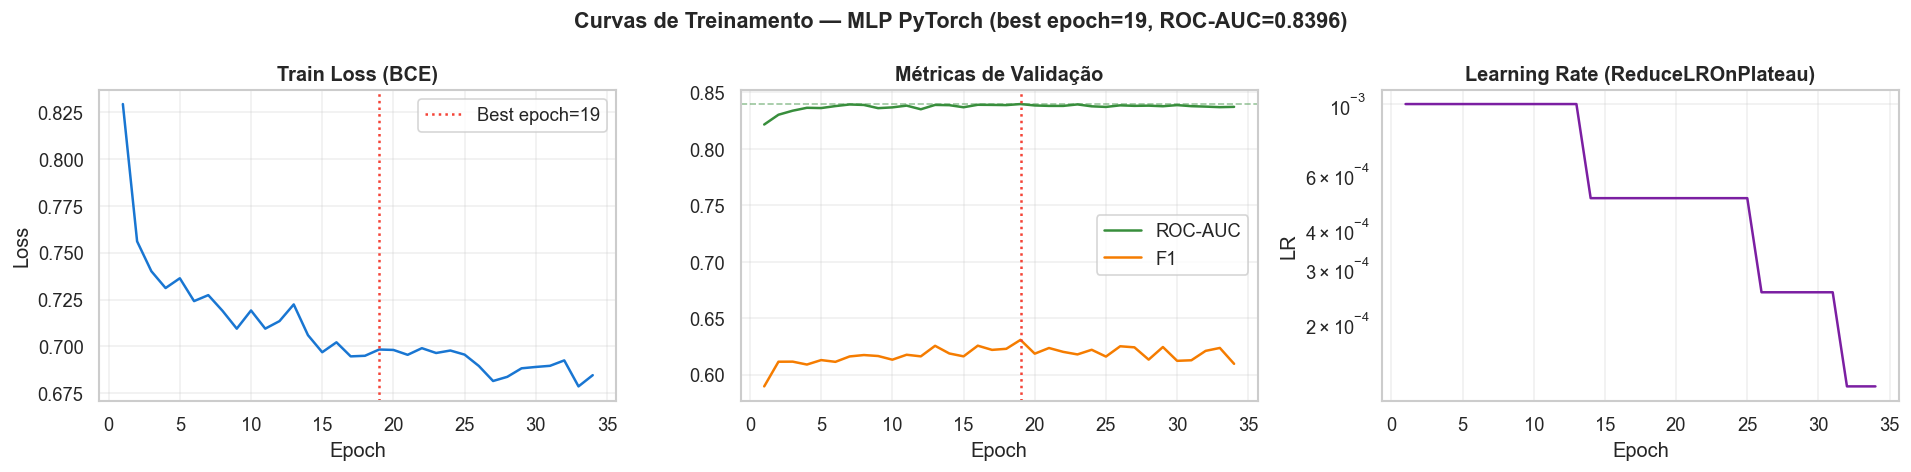

In [12]:
epochs_ax = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_ax, history['train_loss'], color='#1976D2', linewidth=1.5)
axes[0].set_title('Train Loss (BCE)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].axvline(best_epoch, color='#F44336', linestyle=':', linewidth=1.5, label=f'Best epoch={best_epoch}')
axes[0].legend()

axes[1].plot(epochs_ax, history['val_roc_auc'], color='#388E3C', linewidth=1.5, label='ROC-AUC')
axes[1].plot(epochs_ax, history['val_f1'],      color='#F57C00', linewidth=1.5, label='F1')
axes[1].axvline(best_epoch, color='#F44336', linestyle=':', linewidth=1.5)
axes[1].axhline(max(history['val_roc_auc']), color='#388E3C', linestyle='--', alpha=0.5, linewidth=1)
axes[1].set_title('Métricas de Validação', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs_ax, history['lr'], color='#7B1FA2', linewidth=1.5)
axes[2].set_title('Learning Rate (ReduceLROnPlateau)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log')

plt.suptitle(f'Curvas de Treinamento — MLP PyTorch (best epoch={best_epoch}, ROC-AUC={best_roc_auc:.4f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Tabela Comparativa de Modelos

In [13]:
# ── Constrói tabela comparativa ───────────────────────────────────────────────
METRIC_COLS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
COL_LABELS  = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

table_data = []
for model_name, res in all_results.items():
    row = {'Modelo': model_name}
    row.update({lbl: res[m] for m, lbl in zip(METRIC_COLS, COL_LABELS)})
    row['Net Value (R$)'] = res['opt_net']
    row['Threshold*']     = res['opt_thr']
    table_data.append(row)

comparison_df = pd.DataFrame(table_data).set_index('Modelo')

print('=' * 90)
print('  TABELA COMPARATIVA DE MODELOS — TELCO CHURN')
print('=' * 90)
print(comparison_df.to_string(float_format='%.4f'))
print()
print('  * Threshold ótimo = maximiza valor líquido de negócio')

  TABELA COMPARATIVA DE MODELOS — TELCO CHURN
                    Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC  Net Value (R$)  Threshold*
Modelo                                                                                             
LogisticRegression    0.8070     0.6584  0.5668 0.6092   0.8416  0.6322     108608.9200      0.1000
DecisionTree          0.7346     0.5000  0.8075 0.6176   0.8308  0.5976     109390.5000      0.1000
RandomForest          0.7573     0.5291  0.7781 0.6299   0.8411  0.6517     109264.1400      0.1000
GradientBoosting      0.7999     0.6533  0.5241 0.5816   0.8433  0.6560     108228.9600      0.1000
MLP_PyTorch           0.7566     0.5279  0.7834 0.6308   0.8396  0.6267     109812.9000      0.1000

  * Threshold ótimo = maximiza valor líquido de negócio


In [14]:
# ── Tabela estilizada (pandas Styler) ─────────────────────────────────────────
styled = (
    comparison_df.style
    .highlight_max(axis=0, subset=COL_LABELS,        color='#c8e6c9')  # melhor métrica em verde
    .highlight_min(axis=0, subset=COL_LABELS,        color='#ffcdd2')  # pior métrica em vermelho
    .highlight_max(axis=0, subset=['Net Value (R$)'], color='#fff9c4')  # melhor valor em amarelo
    .format({
        **{c: '{:.4f}' for c in COL_LABELS},
        'Net Value (R$)': 'R$ {:,.2f}',
        'Threshold*'    : '{:.2f}',
    })
    .set_caption('Comparação de Modelos — Verde = melhor, Vermelho = pior')
)
styled

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Net Value (R$),Threshold*
Modelo,,,,,,,,
LogisticRegression,0.8070,0.6584,0.5668,0.6092,0.8416,0.6322,"R$ 108,608.92",0.10
DecisionTree,0.7346,0.5000,0.8075,0.6176,0.8308,0.5976,"R$ 109,390.50",0.10
RandomForest,0.7573,0.5291,0.7781,0.6299,0.8411,0.6517,"R$ 109,264.14",0.10
GradientBoosting,0.7999,0.6533,0.5241,0.5816,0.8433,0.6560,"R$ 108,228.96",0.10
MLP_PyTorch,0.7566,0.5279,0.7834,0.6308,0.8396,0.6267,"R$ 109,812.90",0.10


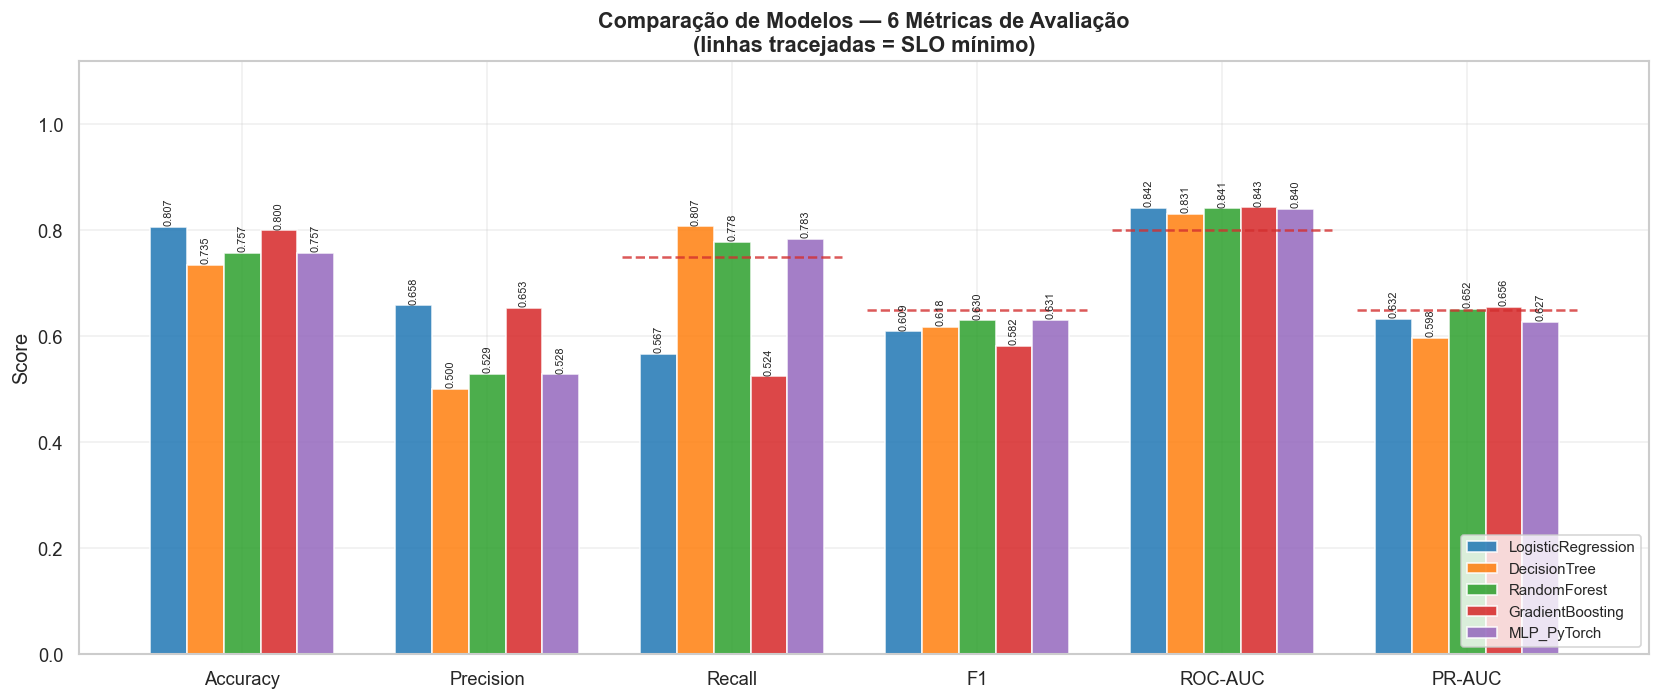

In [15]:
# ── Gráfico de barras: todas as métricas × todos os modelos ───────────────────
n_models = len(comparison_df)
palette  = sns.color_palette('tab10', n_models)
width    = 0.15
x        = np.arange(len(COL_LABELS))

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    offset = (i - n_models / 2 + 0.5) * width
    bars   = ax.bar(x + offset, row[COL_LABELS].values, width,
                    label=model_name, color=palette[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

# Linhas de SLO
SLOs = {'Recall': 0.75, 'F1': 0.65, 'ROC-AUC': 0.80, 'PR-AUC': 0.65}
for metric, slo in SLOs.items():
    idx = COL_LABELS.index(metric)
    ax.plot([idx - 0.45, idx + 0.45], [slo, slo],
            color='#D32F2F', linestyle='--', linewidth=1.5, alpha=0.8)

ax.set_xticks(x); ax.set_xticklabels(COL_LABELS, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.12)
ax.set_title('Comparação de Modelos — 6 Métricas de Avaliação\n(linhas tracejadas = SLO mínimo)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_ROOT, 'metrics_comparison.png'), bbox_inches='tight')
plt.show()

## 10. Curvas ROC e Precision-Recall

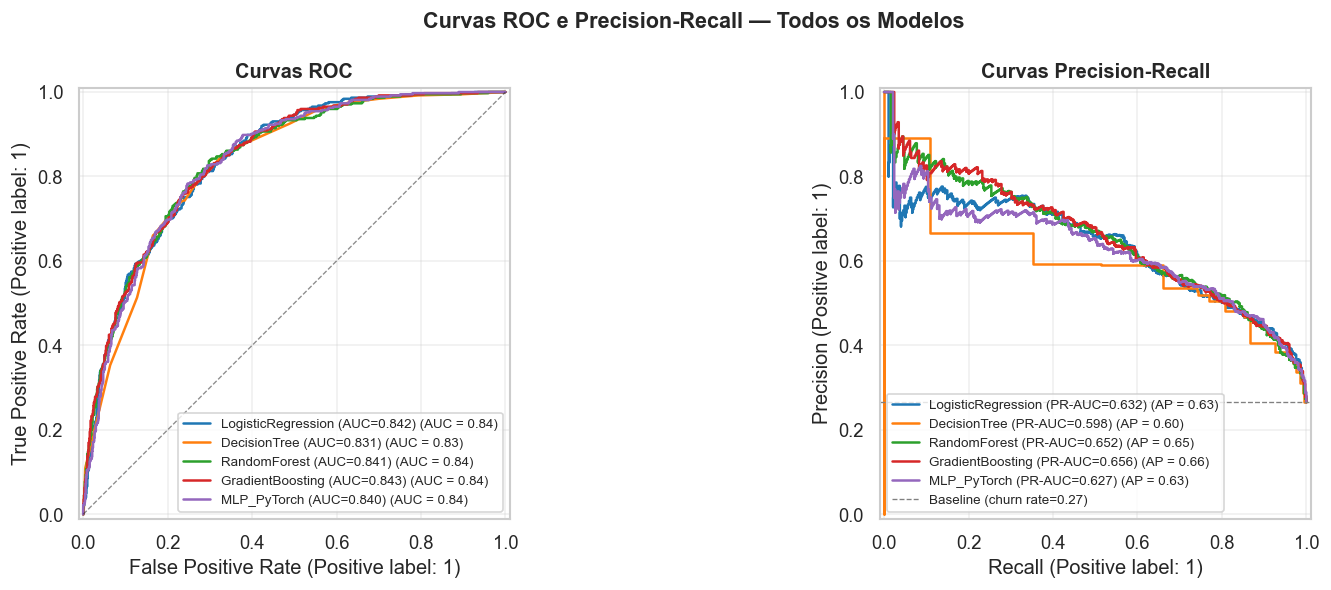

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, probs) in enumerate(all_probs_dict.items()):
    RocCurveDisplay.from_predictions(
        y_test.values, probs,
        name=f"{name} (AUC={all_results[name]['roc_auc']:.3f})",
        ax=axes[0], curve_kwargs={'color': palette[i]},
    )
    PrecisionRecallDisplay.from_predictions(
        y_test.values, probs,
        name=f"{name} (PR-AUC={all_results[name]['pr_auc']:.3f})",
        ax=axes[1], curve_kwargs={'color': palette[i]},
    )

axes[0].set_title('Curvas ROC', fontweight='bold')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
axes[0].legend(fontsize=8)

axes[1].set_title('Curvas Precision-Recall', fontweight='bold')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', linewidth=0.8,
                label=f'Baseline (churn rate={y_test.mean():.2f})')
axes[1].legend(fontsize=8)

plt.suptitle('Curvas ROC e Precision-Recall — Todos os Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_ROOT, 'roc_pr_curves.png'), bbox_inches='tight')
plt.show()

## 11. Análise de Custo: Trade-off FP × FN

Para o problema de churn, o custo assimétrico é central:

- **Falso Negativo (FN)**: Cliente churna sem receber campanha → perda de R$ ARPU × 12 meses
- **Falso Positivo (FP)**: Campanha enviada a cliente que não churna → custo de R$ ARPU × 0.30

A razão FN/FP ≈ **40×** justifica configurar um threshold baixo para priorizar **Recall** sobre **Precision**.

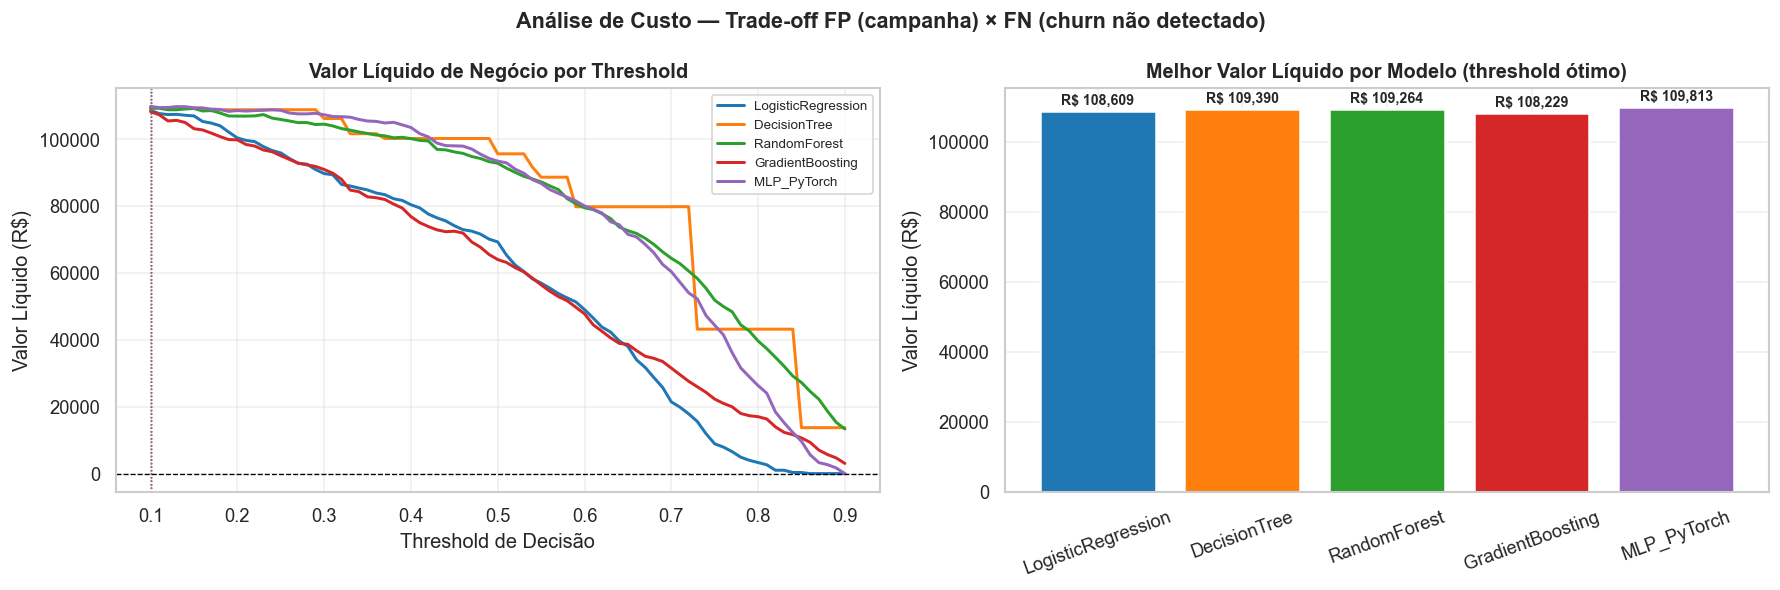


Resultados de Custo por Modelo (threshold ótimo):
                    best_threshold  best_net_value  recall_at_best  precision_at_best
LogisticRegression          0.1000     108608.9200          0.9465             0.4060
DecisionTree                0.1000     109390.5000          0.9759             0.3571
RandomForest                0.1000     109264.1400          0.9840             0.3411
GradientBoosting            0.1000     108228.9600          0.9412             0.4112
MLP_PyTorch                 0.1000     109812.9000          0.9893             0.3404


In [17]:
# ── Varredura de threshold: valor líquido por modelo ─────────────────────────
thresholds = np.linspace(0.1, 0.9, 81)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

best_biz = {}
for i, (name, probs) in enumerate(all_probs_dict.items()):
    net_vals, recalls_t, precisions_t = [], [], []
    for thr in thresholds:
        preds_t = (probs >= thr).astype(int)
        bm = compute_business_metrics(y_test.values, preds_t)
        net_vals.append(bm['biz_net_value'])
        recalls_t.append(recall_score(y_test.values, preds_t, zero_division=0))
        precisions_t.append(precision_score(y_test.values, preds_t, zero_division=0))
    best_idx = int(np.argmax(net_vals))
    best_biz[name] = {
        'best_threshold': round(thresholds[best_idx], 2),
        'best_net_value': round(net_vals[best_idx], 2),
        'recall_at_best' : round(recalls_t[best_idx], 4),
        'precision_at_best': round(precisions_t[best_idx], 4),
    }
    axes[0].plot(thresholds, net_vals, label=name, color=palette[i], linewidth=1.8)
    axes[0].axvline(thresholds[best_idx], color=palette[i], linestyle=':', linewidth=0.8)

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Valor Líquido de Negócio por Threshold', fontweight='bold')
axes[0].set_xlabel('Threshold de Decisão')
axes[0].set_ylabel('Valor Líquido (R$)')
axes[0].legend(fontsize=8)

# Barra: melhor valor por modelo
best_nets = [best_biz[name]['best_net_value'] for name in all_probs_dict]
bars = axes[1].bar(list(all_probs_dict.keys()), best_nets, color=palette[:len(best_nets)],
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, best_nets):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h + max(best_nets) * 0.01,
                 f'R$ {val:,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[1].set_title('Melhor Valor Líquido por Modelo (threshold ótimo)', fontweight='bold')
axes[1].set_ylabel('Valor Líquido (R$)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Análise de Custo — Trade-off FP (campanha) × FN (churn não detectado)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_ROOT, 'cost_analysis.png'), bbox_inches='tight')
plt.show()

# Tabela de resultados de custo
cost_table = pd.DataFrame(best_biz).T
print('\nResultados de Custo por Modelo (threshold ótimo):')
print(cost_table.to_string(float_format='%.4f'))

In [18]:
# ── Decomposição do custo: TP, FP, FN, TN por modelo ─────────────────────────
cost_breakdown = []
for name, probs in all_probs_dict.items():
    thr  = best_biz[name]['best_threshold']
    preds = (probs >= thr).astype(int)
    bm    = compute_business_metrics(y_test.values, preds)
    cost_breakdown.append({
        'Modelo'             : name,
        'TP (retidos)'       : bm['biz_tp'],
        'FP (campanha vã)'   : bm['biz_fp'],
        'FN (churn perdido)' : bm['biz_fn'],
        'TN'                 : bm['biz_tn'],
        'Savings (R$)'       : bm['biz_savings'],
        'Cost FP (R$)'       : bm['biz_cost_fp'],
        'Cost FN (R$)'       : bm['biz_cost_fn'],
        'Net Value (R$)'     : bm['biz_net_value'],
        'Threshold*'         : thr,
    })

cost_df = pd.DataFrame(cost_breakdown).set_index('Modelo')
print('Decomposição de Custo por Modelo (threshold ótimo):')
print()
cost_df.style\
    .highlight_max(axis=0, subset=['TP (retidos)', 'Savings (R$)', 'Net Value (R$)'], color='#c8e6c9')\
    .highlight_min(axis=0, subset=['FN (churn perdido)', 'Cost FN (R$)'],             color='#c8e6c9')\
    .format({'Savings (R$)': 'R$ {:,.2f}', 'Cost FP (R$)': 'R$ {:,.2f}',
             'Cost FN (R$)': 'R$ {:,.2f}', 'Net Value (R$)': 'R$ {:,.2f}'})

Decomposição de Custo por Modelo (threshold ótimo):



,TP (retidos),FP (campanha vã),FN (churn perdido),TN,Savings (R$),Cost FP (R$),Cost FN (R$),Net Value (R$),Threshold*
Modelo,,,,,,,,,
LogisticRegression,354,518,20,517,"R$ 119,538.72","R$ 10,929.80","R$ 16,884.00","R$ 108,608.92",0.100000
DecisionTree,365,657,9,378,"R$ 123,253.20","R$ 13,862.70","R$ 7,597.80","R$ 109,390.50",0.100000
RandomForest,368,711,6,324,"R$ 124,266.24","R$ 15,002.10","R$ 5,065.20","R$ 109,264.14",0.100000
GradientBoosting,352,504,22,531,"R$ 118,863.36","R$ 10,634.40","R$ 18,572.40","R$ 108,228.96",0.100000
MLP_PyTorch,370,717,4,318,"R$ 124,941.60","R$ 15,128.70","R$ 3,376.80","R$ 109,812.90",0.100000


## 12. Sumário Final

In [ ]:
best_auc    = comparison_df['ROC-AUC'].idxmax()
best_recall = comparison_df['Recall'].idxmax()
best_f1     = comparison_df['F1'].idxmax()
best_net    = max(best_biz, key=lambda n: best_biz[n]['best_net_value'])

print('=' * 70)
print('  SUMARIO DO EXPERIMENTO - TELCO CHURN MLP')
print('=' * 70)
print(f'\n  Dataset    : {len(df):,} clientes | {X.shape[1]} features | churn={y.mean()*100:.1f}%')
print(f'  Modelos    : {len(all_results)} (LR, DT, RF, GB, MLP)')
print(f'  Metricas   : Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC (6 total)')

print(f'\n  Ranking por metrica:')
print(f'    Melhor ROC-AUC    : {best_auc:<22} {comparison_df.loc[best_auc, "ROC-AUC"]:.4f}')
print(f'    Melhor Recall     : {best_recall:<22} {comparison_df.loc[best_recall, "Recall"]:.4f}')
print(f'    Melhor F1         : {best_f1:<22} {comparison_df.loc[best_f1, "F1"]:.4f}')
print(f'    Melhor Net Value  : {best_net:<22} R$ {best_biz[best_net]["best_net_value"]:,.2f}')

print(f'\n  MLP PyTorch:')
print(f'    Parametros       : {mlp.num_parameters:,}')
print(f'    Arquitetura      : {HPARAMS["hidden_dims"]}')
print(f'    Early stopping   : epoch {best_epoch} (patience={HPARAMS["patience"]})')
print(f'    Melhor ROC-AUC   : {best_roc_auc:.4f}')

print(f'\n  Verificacao de SLOs:')
slo_checks = [('ROC-AUC', 0.80), ('PR-AUC', 0.65), ('Recall', 0.75), ('F1', 0.65)]
for metric, slo in slo_checks:
    best_val = comparison_df[metric].max()
    status   = '[OK]' if best_val >= slo else '[ABAIXO]'
    print(f'    {metric:<10}: SLO={slo} | Melhor={best_val:.4f} | {status}')

print(f'\n  Artefatos MLflow: {MLFLOW_TRACKING_URI}')
print(f'  Comando: mlflow ui --backend-store-uri "{MLFLOW_TRACKING_URI}"')
print('=' * 70)

  SUMARIO DO EXPERIMENTO - TELCO CHURN MLP

  Dataset    : 7,043 clientes | 30 features | churn=26.5%
  Modelos    : 5 (LR, DT, RF, GB, MLP)
  Metricas   : Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC (6 total)

  Ranking por metrica:
    Melhor ROC-AUC    : GradientBoosting       0.8433
    Melhor Recall     : DecisionTree           0.8075
    Melhor F1         : MLP_PyTorch            0.6308
    Melhor Net Value  : MLP_PyTorch            R$ 109,812.90

  MLP PyTorch:
    Parametros       : 14,785
    Arquitetura      : [128, 64, 32]
    Early stopping   : epoch 19 (patience=15)
    Melhor ROC-AUC   : 0.8396

  Verificacao de SLOs:
    ROC-AUC   : SLO=0.8 | Melhor=0.8433 | [OK]
    PR-AUC    : SLO=0.65 | Melhor=0.6560 | [OK]
    Recall    : SLO=0.75 | Melhor=0.8075 | [OK]
    F1        : SLO=0.65 | Melhor=0.6308 | [ABAIXO]

  Artefatos MLflow: sqlite:///c:\Users\Hugo\OneDrive\Documentos\Projeto Pós\ml-project\mlflow.db
  Comando: mlflow ui --backend-store-uri "sqlite:///c:\Users\H

: 